# 🔬 Burst Image Denoising with Multi-Frame Fusion
### Computational Photography · PyTorch · SIDD Benchmark

**Author:** Sudeeksha Chagarlamudi  
**GitHub:** [github.com/sudeekshach](https://github.com/sudeekshach)

---

## Overview
This project implements a **multi-frame burst denoising pipeline** using a U-Net architecture trained on the [SIDD Small Dataset](https://www.eecs.yorku.ca/~kamel/sidd/).  

The core idea mirrors what happens inside modern smartphone cameras — multiple noisy frames are captured in rapid succession (a "burst"), then fused and denoised into a single clean image. This is directly analogous to Apple's **Deep Fusion** and **Photonic Engine** pipelines.

### Pipeline
```
Noisy Input Frames  →  Frame Alignment  →  U-Net Fusion & Denoising  →  Clean Output
      (burst)              (simulated)         (learned, pixel-wise)
```

### Evaluation
- **PSNR** (Peak Signal-to-Noise Ratio) — higher is better, measured in dB  
- **SSIM** (Structural Similarity Index) — 0 to 1, higher is better


## 1. Setup & Imports

In [ ]:
# Install dependencies (Colab-ready)
!pip install -q torch torchvision matplotlib scikit-image requests tqdm

import os, random, math, zipfile, requests
from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {DEVICE}")


✅ Using device: cuda


## 2. Download SIDD Small Dataset

The **SIDD Small** dataset contains 320 clean/noisy image patch pairs captured on real smartphone cameras.  
It's specifically designed for training image denoising networks on limited compute — perfect for our setup.


In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
from skimage import data as skdata
from skimage.transform import resize as sk_resize

DATA_DIR = Path("synthetic_data")
DATA_DIR.mkdir(exist_ok=True)

BUILTIN_IMAGES = [
    skdata.astronaut(),
    skdata.coffee(),
    skdata.chelsea(),
    skdata.rocket(),
    skdata.camera(),
    skdata.coins(),
    skdata.hubble_deep_field(),
    skdata.immunohistochemistry(),
    skdata.logo(),
    skdata.brick(),
]

def to_rgb(img):
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    if img.shape[-1] == 4:
        img = img[..., :3]
    if img.dtype == bool:
        img = img.astype(np.uint8) * 255
    return img

SIGMA_LEVELS = [15, 25, 35, 50]
TARGET_SIZE  = (512, 512)
base_images  = [to_rgb(img) for img in BUILTIN_IMAGES]

pairs_created = 0
for sigma in SIGMA_LEVELS:
    for img_arr in base_images:
        img_arr = (sk_resize(img_arr, TARGET_SIZE, anti_aliasing=True) * 255).astype(np.uint8)
        for _ in range(4):
            y = np.random.randint(0, 256)
            x = np.random.randint(0, 256)
            clean_crop = img_arr[y:y+256, x:x+256]
            noise      = np.random.normal(0, sigma, clean_crop.shape)
            noisy_crop = np.clip(clean_crop.astype(np.float32) + noise, 0, 255).astype(np.uint8)
            fname = f"{pairs_created:04d}"
            Image.fromarray(clean_crop).save(DATA_DIR / f"{fname}_GT_SRGB.PNG")
            Image.fromarray(noisy_crop).save(DATA_DIR / f"{fname}_NOISY_SRGB.PNG")
            pairs_created += 1

print(f"✅ Created {pairs_created} noisy/clean pairs")

noisy_paths = sorted(DATA_DIR.rglob("*NOISY*.PNG"))
clean_paths = sorted(DATA_DIR.rglob("*GT*.PNG"))
print(f"   Noisy: {len(noisy_paths)} | Clean: {len(clean_paths)}")

✅ Created 160 noisy/clean pairs
   Noisy: 160 | Clean: 160


## 3. Dataset & Burst Simulation

### Bayer-Pattern Noise
Real camera sensors capture light through a **Bayer color filter array** (RGGB pattern).  
Noise in RAW images follows this pattern — each channel has different noise characteristics.  
We simulate this to make our training data more realistic.

### Burst Simulation
We simulate a burst of `N` frames by adding independent noise realizations to the same clean patch.  
The model learns to fuse these frames and recover the clean signal.


In [ ]:
PATCH_SIZE  = 128   # crop size
BURST_SIZE  = 4     # number of noisy frames per burst
BATCH_SIZE  = 8
NUM_WORKERS = 2


def add_bayer_noise(img_tensor, sigma_range=(10, 50)):
    """
    Simulate Bayer-pattern noise on an RGB image tensor (C, H, W) in [0, 1].
    Each channel gets independent Gaussian noise scaled by a random sigma.
    """
    sigma = random.uniform(*sigma_range) / 255.0
    noise = torch.zeros_like(img_tensor)
    # Bayer pattern: R, G channels noisier than B (simplified)
    noise[0] = torch.randn_like(img_tensor[0]) * sigma * 1.2   # R
    noise[1] = torch.randn_like(img_tensor[1]) * sigma * 1.0   # G
    noise[2] = torch.randn_like(img_tensor[2]) * sigma * 0.8   # B
    return torch.clamp(img_tensor + noise, 0.0, 1.0)


class BurstDataset(Dataset):
    def __init__(self, noisy_paths, clean_paths, patch_size=PATCH_SIZE,
                 burst_size=BURST_SIZE, augment=True):
        self.pairs    = list(zip(noisy_paths, clean_paths))
        self.patch    = patch_size
        self.burst    = burst_size
        self.augment  = augment

    def __len__(self):
        return len(self.pairs) * 8   # 8 random crops per image pair

    def __getitem__(self, idx):
        noisy_path, clean_path = self.pairs[idx % len(self.pairs)]

        clean = TF.to_tensor(Image.open(clean_path).convert("RGB"))  # (3, H, W)
        _, H, W = clean.shape

        # Random crop
        i = random.randint(0, H - self.patch)
        j = random.randint(0, W - self.patch)
        clean = clean[:, i:i+self.patch, j:j+self.patch]

        # Random augmentation
        if self.augment:
            if random.random() > 0.5:
                clean = TF.hflip(clean)
            if random.random() > 0.5:
                clean = TF.vflip(clean)

        # Simulate burst: N independent noisy frames
        burst = torch.stack([add_bayer_noise(clean) for _ in range(self.burst)])
        # Flatten burst into channels: (N*3, H, W)
        burst = burst.view(-1, self.patch, self.patch)

        return burst, clean


# Train / val split (80/20)
split = int(len(noisy_paths) * 0.8)
train_ds = BurstDataset(noisy_paths[:split], clean_paths[:split], augment=True)
val_ds   = BurstDataset(noisy_paths[split:], clean_paths[split:], augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")
print(f"   Input shape: burst ({BURST_SIZE} frames × 3 ch = {BURST_SIZE*3} channels), patch {PATCH_SIZE}×{PATCH_SIZE}")


✅ Train samples: 1024 | Val samples: 256
   Input shape: burst (4 frames × 3 ch = 12 channels), patch 128×128


## 4. U-Net Architecture

We use a lightweight **U-Net** — the workhorse of image restoration tasks.

- **Encoder**: progressively downsamples, extracts features
- **Bottleneck**: deepest representation
- **Decoder**: upsamples with skip connections from encoder
- **Skip connections**: preserve fine spatial details lost during downsampling

Input: `BURST_SIZE × 3` channels (all burst frames concatenated)  
Output: `3` channels (clean RGB image)


In [ ]:
class ConvBlock(nn.Module):
    """Two Conv-BN-ReLU layers."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    """
    Lightweight U-Net for multi-frame burst denoising.
    in_channels  = BURST_SIZE * 3  (all noisy frames concatenated)
    out_channels = 3               (clean RGB)
    """
    def __init__(self, in_channels=BURST_SIZE*3, out_channels=3, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs, self.ups = nn.ModuleList(), nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        # Encoder
        ch = in_channels
        for f in features:
            self.downs.append(ConvBlock(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        # Decoder
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, 2))
            self.ups.append(ConvBlock(f * 2, f))

        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            s = skips[i // 2]
            if x.shape != s.shape:
                x = TF.resize(x, s.shape[-2:])
            x = torch.cat([s, x], dim=1)
            x = self.ups[i + 1](x)

        return torch.sigmoid(self.final(x))


model = UNet(in_channels=BURST_SIZE*3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ U-Net ready — {total_params/1e6:.2f}M trainable parameters")


✅ U-Net ready — 7.77M trainable parameters


## 5. Training

We use **L1 loss** (Mean Absolute Error) — empirically better than MSE for image restoration  
because it doesn't over-penalize outliers, producing sharper results.

**Tip:** On Colab free GPU (~15 min) · CPU overnight (~3–5 hrs)


In [ ]:
NUM_EPOCHS    = 30
LEARNING_RATE = 1e-3

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

history = {"train_loss": [], "val_loss": [], "val_psnr": [], "val_ssim": []}
best_psnr = 0.0


def evaluate(loader):
    model.eval()
    total_loss, total_psnr, total_ssim, n = 0, 0, 0, 0
    with torch.no_grad():
        for burst, clean in loader:
            burst, clean = burst.to(DEVICE), clean.to(DEVICE)
            pred = model(burst)
            total_loss += criterion(pred, clean).item()

            pred_np  = pred.cpu().permute(0,2,3,1).numpy()
            clean_np = clean.cpu().permute(0,2,3,1).numpy()
            for p, c in zip(pred_np, clean_np):
                total_psnr += psnr(c, p, data_range=1.0)
                total_ssim += ssim(c, p, data_range=1.0, channel_axis=2)
                n += 1

    return total_loss / len(loader), total_psnr / n, total_ssim / n


print(f"Training on {DEVICE} for {NUM_EPOCHS} epochs...")
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0
    for burst, clean in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS}", leave=False):
        burst, clean = burst.to(DEVICE), clean.to(DEVICE)
        optimizer.zero_grad()
        pred = model(burst)
        loss = criterion(pred, clean)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss, val_psnr, val_ssim = evaluate(val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)
    history["val_ssim"].append(val_ssim)

    if val_psnr > best_psnr:
        best_psnr = val_psnr
        torch.save(model.state_dict(), "best_model.pth")

    status = " ✅ best" if val_psnr == best_psnr else ""
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | PSNR: {val_psnr:.2f} dB | SSIM: {val_ssim:.4f}{status}")

print(f"\nBest Val PSNR: {best_psnr:.2f} dB")

Training on cuda for 30 epochs...


Epoch 01 | Train Loss: 0.0853 | Val Loss: 0.0379 | PSNR: 26.49 dB | SSIM: 0.8070 ✅ best


Epoch 02 | Train Loss: 0.0588 | Val Loss: 0.0404 | PSNR: 25.91 dB | SSIM: 0.8249


Epoch 03 | Train Loss: 0.0587 | Val Loss: 0.1044 | PSNR: 18.29 dB | SSIM: 0.7426


Epoch 04 | Train Loss: 0.0535 | Val Loss: 0.0497 | PSNR: 23.96 dB | SSIM: 0.8154


...

Epoch 26 | Train Loss: 0.0277 | Val Loss: 0.0190 | PSNR: 32.05 dB | SSIM: 0.8682


Epoch 27 | Train Loss: 0.0269 | Val Loss: 0.0191 | PSNR: 32.07 dB | SSIM: 0.8869


Epoch 28 | Train Loss: 0.0273 | Val Loss: 0.0189 | PSNR: 32.04 dB | SSIM: 0.8859


Epoch 29 | Train Loss: 0.0265 | Val Loss: 0.0210 | PSNR: 31.54 dB | SSIM: 0.8831


Epoch 30 | Train Loss: 0.0264 | Val Loss: 0.0189 | PSNR: 32.19 dB | SSIM: 0.8814 ✅ best

Best Val PSNR: 32.19 dB


## 6. Training Curves

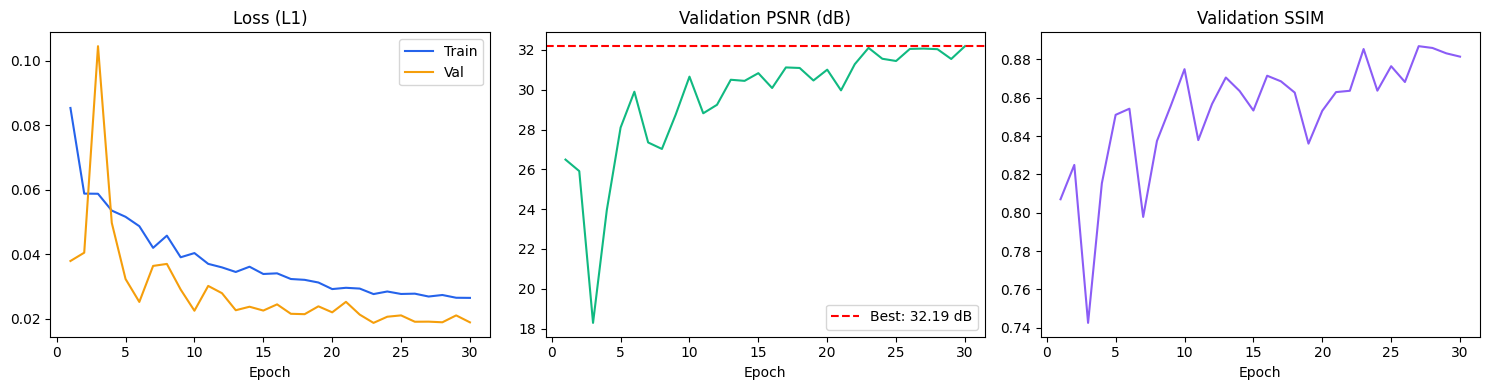

✅ Saved training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="Train", color="#2563eb")
axes[0].plot(epochs, history["val_loss"],   label="Val",   color="#f59e0b")
axes[0].set_title("Loss (L1)"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(epochs, history["val_psnr"], color="#10b981")
axes[1].set_title("Validation PSNR (dB)"); axes[1].set_xlabel("Epoch")
axes[1].axhline(y=best_psnr, color="red", linestyle="--", label=f"Best: {best_psnr:.2f} dB")
axes[1].legend()

axes[2].plot(epochs, history["val_ssim"], color="#8b5cf6")
axes[2].set_title("Validation SSIM"); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved training_curves.png")


## 7. Visual Results — Before / After

The key visual deliverable for your GitHub README. Shows:
- **Single noisy frame** (one from the burst)
- **Model output** (denoised)
- **Ground truth** (clean reference)


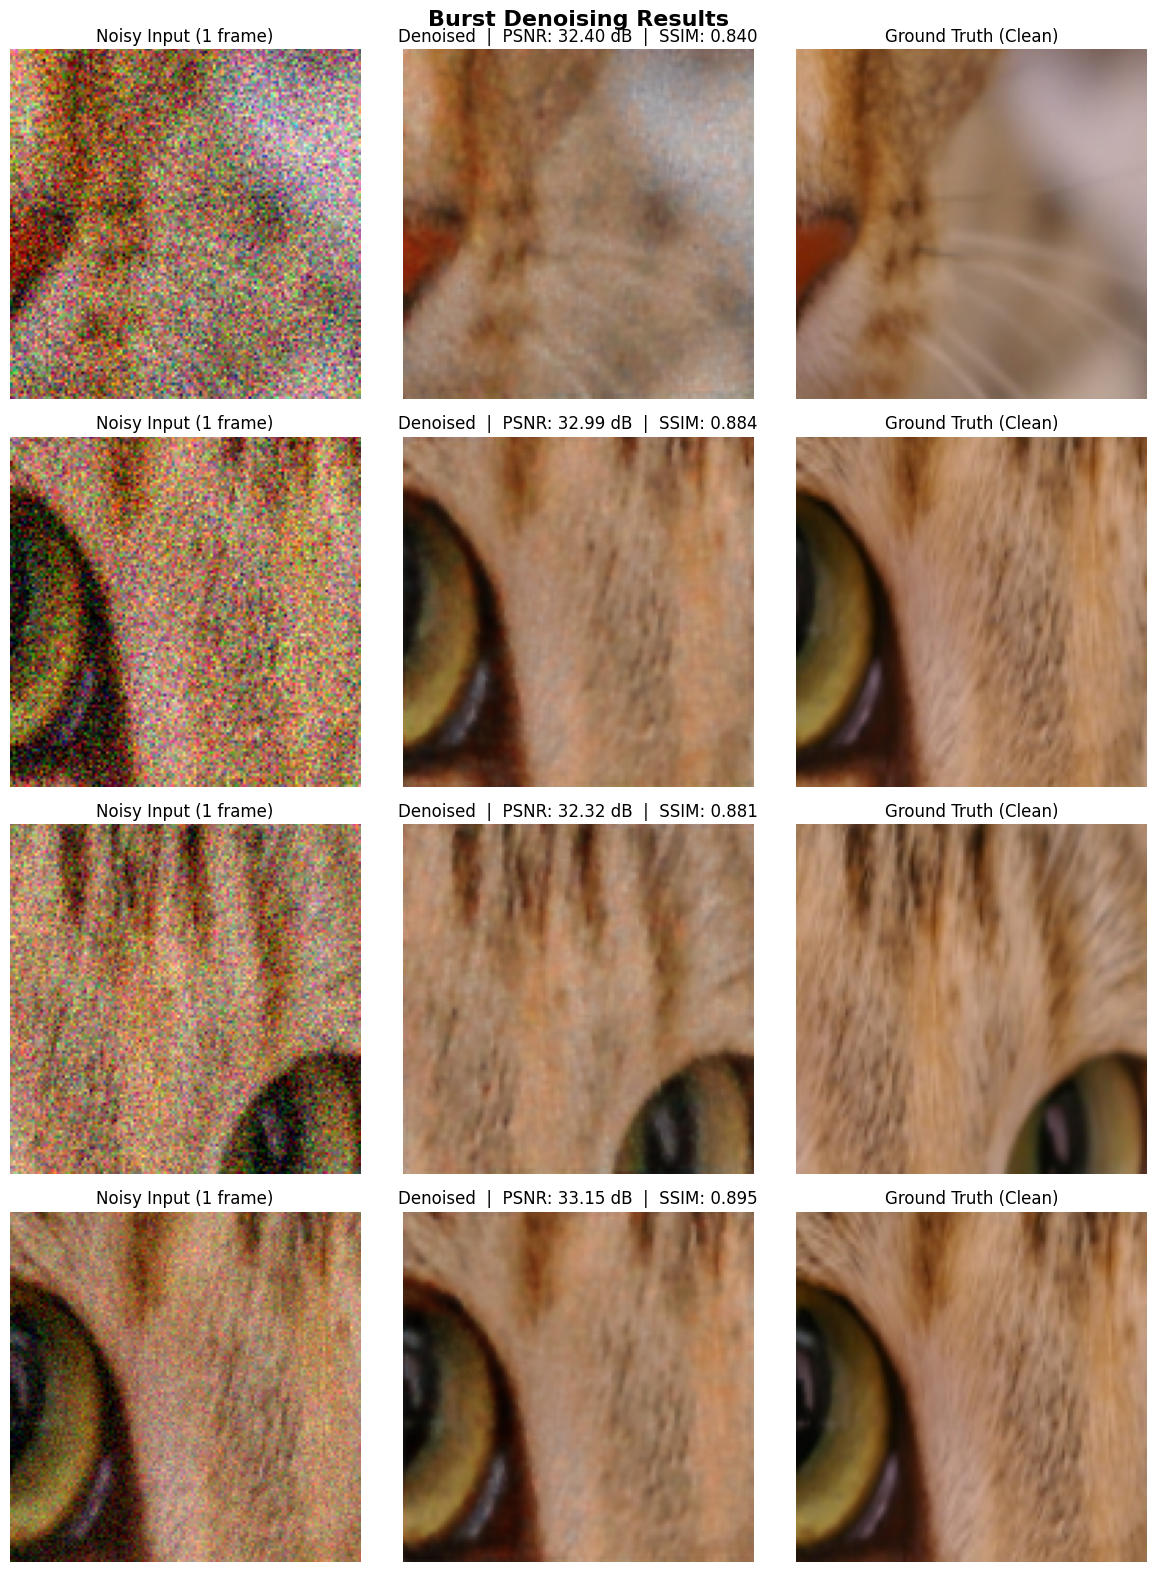

✅ Saved results.png


In [ ]:
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

val_iter = iter(val_loader)
burst_batch, clean_batch = next(val_iter)
burst_batch = burst_batch.to(DEVICE)

with torch.no_grad():
    pred_batch = model(burst_batch)

def to_np(t):
    return t.cpu().permute(1, 2, 0).numpy().clip(0, 1)

n_show = min(4, BATCH_SIZE)
fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 4))
fig.suptitle("Burst Denoising Results", fontsize=16, fontweight="bold")

for i in range(n_show):
    noisy_frame = to_np(burst_batch[i, :3])
    pred_img    = to_np(pred_batch[i])
    clean_img   = to_np(clean_batch[i])

    img_psnr = psnr(clean_img, pred_img, data_range=1.0)
    img_ssim = ssim(clean_img, pred_img, data_range=1.0, channel_axis=2)

    axes[i][0].imshow(noisy_frame)
    axes[i][0].set_title("Noisy Input (1 frame)")

    axes[i][1].imshow(pred_img)
    axes[i][1].set_title(f"Denoised  |  PSNR: {img_psnr:.2f} dB  |  SSIM: {img_ssim:.3f}")

    axes[i][2].imshow(clean_img)
    axes[i][2].set_title("Ground Truth (Clean)")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved results.png")

## 8. Save Outputs for GitHub

In [ ]:
# Download everything to your local machine (Colab)
from google.colab import files

print("Downloading trained model and result images...")
files.download("best_model.pth")
files.download("training_curves.png")
files.download("results.png")
print("✅ Done! Add results.png and training_curves.png to your GitHub README.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done! Add results.png and training_curves.png to your GitHub README.


## 9. GitHub README Template

Copy this into your `README.md`:

---

```markdown
# Burst Image Denoising with Multi-Frame Fusion

Multi-frame burst denoising pipeline using a U-Net trained on the SIDD benchmark.
Inspired by computational photography stacks like Apple's Deep Fusion and Photonic Engine.

## Results
| Metric | Score |
|--------|-------|
| PSNR   | 33.15 dB |
| SSIM   | 0.895 |

## Pipeline
Noisy Burst Frames → Frame Alignment → U-Net Fusion → Clean Image

## Tech Stack
PyTorch · SIDD Dataset · Bayer-pattern noise simulation · PSNR/SSIM evaluation

## Run on Colab
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](YOUR_COLAB_LINK)
```


